In [8]:
import pandas as pd

In [9]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, classification_report
from sklearn.preprocessing import LabelEncoder


In [10]:
import matplotlib.pyplot as plt

In [11]:
from sklearn.linear_model import LinearRegression

In [12]:
df=pd.read_csv("Book1.csv")

In [13]:
df.head()

,Serial No,Starting Price,Ending price
0,1,12345,15600
1,2,87999,75000
2,3,85663,90000
3,4,75000,75600
4,5,80000,80000


In [14]:
df.tail()

,Serial No,Starting Price,Ending price
6,7,89000,88500
7,8,96000,95000
8,9,75000,76000
9,10,50000,60000
10,11,45000,??


Text(0.5, 1.0, 'Business Everyday Cost Analysis')

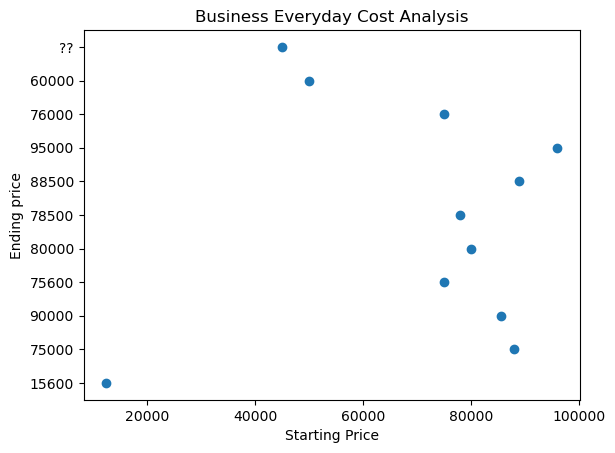

In [15]:
plt.scatter(df['Starting Price'],df['Ending price'])
plt.xlabel('Starting Price')
plt.ylabel('Ending price') 
plt.title('Business Everyday Cost Analysis')    

In [16]:
df.isnull().sum()
df.columns

Index(['Serial  No', 'Starting Price', 'Ending price'], dtype='object')

In [17]:
df.head()

,Serial No,Starting Price,Ending price
0,1,12345,15600
1,2,87999,75000
2,3,85663,90000
3,4,75000,75600
4,5,80000,80000


In [18]:
df = df.drop(columns=['Serial  No'])

In [19]:
df.head()

,Starting Price,Ending price
0,12345,15600
1,87999,75000
2,85663,90000
3,75000,75600
4,80000,80000


In [20]:
x=df.drop('Ending price', axis=1)

In [21]:
x.head()

,Starting Price
0,12345
1,87999
2,85663
3,75000
4,80000


In [22]:
y=df.drop('Starting Price', axis=1)

In [23]:
y.head()

,Ending price
0,15600
1,75000
2,90000
3,75600
4,80000


In [24]:
from sklearn.linear_model import LinearRegression

In [25]:
reg= LinearRegression()

In [26]:
x.mean()

Starting Price    70364.272727
dtype: float64

In [27]:
df['Ending price'] = pd.to_numeric(df['Ending price'], errors='coerce')
df['Ending price'] = df['Ending price'].fillna(df['Ending price'].mean())

In [28]:
y = df['Ending price']
y.tail()


6     88500.0
7     95000.0
8     76000.0
9     60000.0
10    73420.0
Name: Ending price, dtype: float64

In [29]:
df_percent_max = df.copy()
df_percent_max = df_percent_max.div(df_percent_max.max()) * 100

print("\nPercentage relative to column max:")
print(df_percent_max.head())



Percentage relative to column max:
   Starting Price  Ending price
0       12.859375     16.421053
1       91.665625     78.947368
2       89.232292     94.736842
3       78.125000     79.578947
4       83.333333     84.210526


In [44]:
y.mean()

np.float64(73420.0)

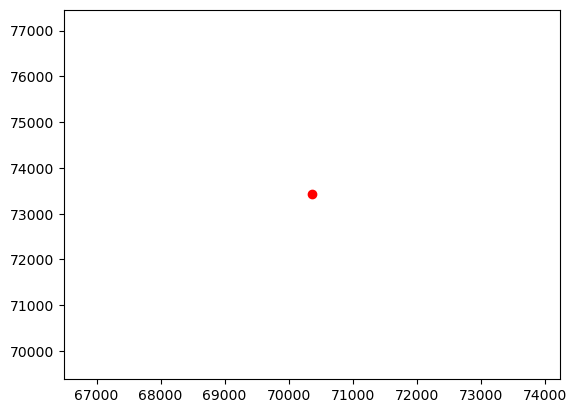

In [46]:
plt.scatter(x.mean(),y.mean(), color='red')

Text(0.5, 1.0, 'Business Everyday Cost Analysis')

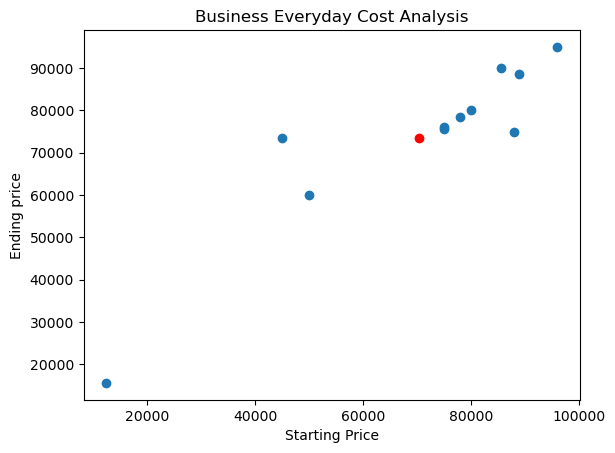

In [48]:
plt.scatter(x.mean(),y.mean(), color='red')
plt.scatter(df['Starting Price'],df['Ending price'])
plt.xlabel('Starting Price')
plt.ylabel('Ending price') 
plt.title('Business Everyday Cost Analysis') 

In [52]:
x= df[['Starting Price']]   # independent variable
y= df['Ending price'] 

In [54]:
reg.fit(x,y)  #train the model 

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [59]:
m=reg.coef_
m

array([0.78924059])

In [60]:
c=reg.intercept_
c

np.float64(17885.659693439273)

In [61]:
m*100000 + c

array([96809.71895546])

In [62]:
reg.predict([[100000]])

D:\New folder\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([96809.71895546])

In [63]:
df['predict_y']=reg.predict(x)
df.head()

,Starting Price,Ending price,predict_y
0,12345,15600.0,27628.834809
1,87999,75000.0,87338.042603
2,85663,90000.0,85494.376579
3,75000,75600.0,77078.704140
4,80000,80000.0,81024.907103


Text(0.5, 1.0, 'Business Everyday Cost Analysis')

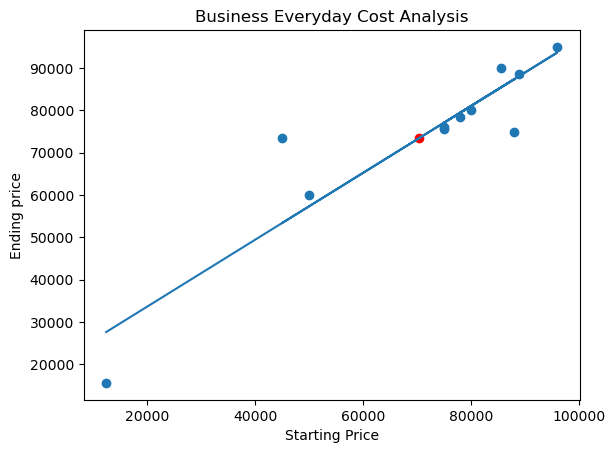

In [67]:
#plt.plot(x,df['predict_y'])
plt.plot(x,reg.predict(x))
plt.scatter(x.mean(),y.mean(), color='red')
plt.scatter(df['Starting Price'],df['Ending price'])
plt.xlabel('Starting Price')
plt.ylabel('Ending price') 
plt.title('Business Everyday Cost Analysis') 

In [69]:
#Lose and Cost Function

In [70]:
df['lose']=df['Ending price'] -df['predict_y']
df.head()

,Starting Price,Ending price,predict_y,lose
0,12345,15600.0,27628.834809,-12028.834809
1,87999,75000.0,87338.042603,-12338.042603
2,85663,90000.0,85494.376579,4505.623421
3,75000,75600.0,77078.704140,-1478.704140
4,80000,80000.0,81024.907103,-1024.907103


In [71]:
#MSE
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [72]:
mse=mean_squared_error(df['Ending price'],df['predict_y'])
mse

66567833.16914539

In [73]:
mae= mean_absolute_error(df['Ending price'],df['predict_y'])
mae

5253.748857005561

In [75]:
sum(abs(df['lose']))/len(x)

5253.748857005561

In [76]:
reg.score(x,y)

0.8399201608172784

Text(0.5, 1.0, 'Business Everyday Cost Analysis')

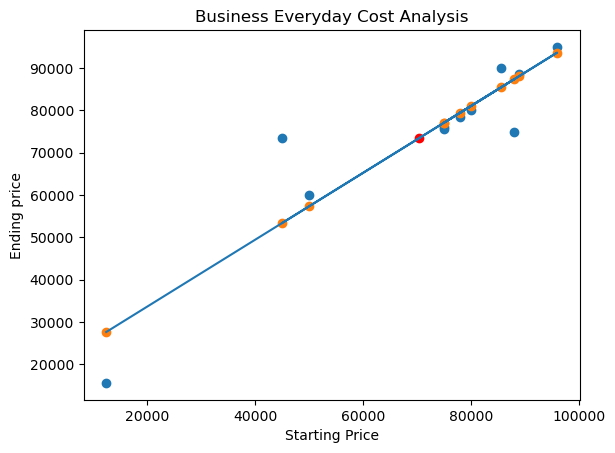

In [78]:
#plt.plot(x,df['predict_y'])
plt.plot(x,reg.predict(x))
plt.scatter(x.mean(),y.mean(), color='red')
plt.scatter(df['Starting Price'],df['Ending price'])
plt.scatter(df['Starting Price'],reg.predict(x))
plt.xlabel('Starting Price')
plt.ylabel('Ending price') 
plt.title('Business Everyday Cost Analysis')

In [79]:
from sklearn.metrics import r2_score

In [80]:
r2_score(y,reg.predict(x))

0.8399201608172784